## 1 input, 1 output 신경망 학습(Activation Function 없이 간략화)

**Wt+1=Wt −𝛼∇𝐿(𝑊𝑡) 공식을 이용해서 weight와 bias 학습**

![2 input, 1 output 학습](Single.png)

**1. Training Set X,Y 설정**

In [6]:
    X = [1,2,3,4]
    Y = [-2, 1, 4, 7]

**2. Hypter Parameter 설정(learning rate, epochs 등)**

In [7]:
import random
import math
weights = random.uniform(-1, 1)
bias = random.uniform(-1, 1)
learning_rate = 0.01
epochs=50

**3. 출력 예측 함수 작성**

In [8]:
def predict(inputs):
    """출력 예측 (순전파)"""
    return weights*inputs + bias

**4. (출력-타겟) 오차를 계산하고 weight_new=weight_old - 학습률*error*입력 공식으로 weight 업데이트**

In [9]:
Loss=[]
for epoch in range(epochs):
    total_error=0
    for inputs,label in zip(X,Y):
        #weighted_sum = sum(w * i for w, i in zip(weights, inputs)) + bias
        prediction = predict(inputs)
        error=prediction-label
        total_error += error**2
        Loss.append(total_error)
        # 3. 경사 계산 및 가중치 업데이트 (경사하강법)
        # d(Error)/d(Weight) = (prediction - label) * input
        
        # d(Error)/d(Bias) = (prediction - label) 
        delta = error 
        weights -= learning_rate * delta * inputs
        bias -= learning_rate * delta
        # 1000회마다 오차 출력
    if epoch % 10 == 0:
        print(f"Epoch {epoch}: Loss = {total_error / len(X):.4f}")
        print(weights, bias)


Epoch 0: Loss = 19.6609
0.21803946192025778 0.14058146164380642
Epoch 10: Loss = 4.6665
1.2916127662577497 0.14990174249682126
Epoch 20: Loss = 4.1382
1.4190836016856316 -0.14845615324811937
Epoch 30: Loss = 3.6597
1.5141229644721075 -0.43765777218919993
Epoch 40: Loss = 3.2361
1.6027933400316818 -0.7098483978553766


**5. 학습 결과 검증**

In [7]:
print("\n--- 학습 결과 테스트 ---")
for inputs in X:
    result = predict(inputs)
    print(f"입력: {inputs}, 예측값: {result:.4f}")



--- 학습 결과 테스트 ---
입력: 1, 예측값: -2.0000
입력: 2, 예측값: 1.0000
입력: 3, 예측값: 4.0000
입력: 4, 예측값: 7.0000


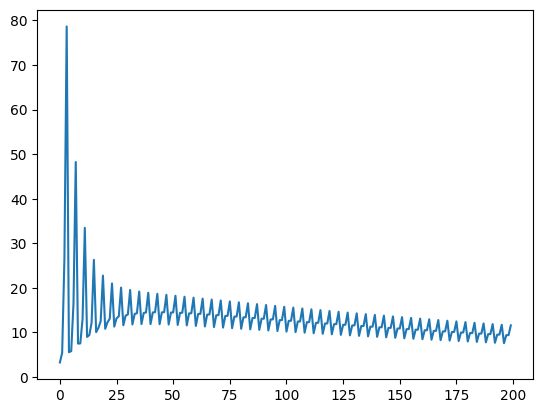

In [10]:
import matplotlib.pyplot as plt
plt.plot(Loss)